In [ ]:
!uv add matplotlib pillow

Resolved 53 packages in 794ms
 Downloaded fonttools
 Downloaded matplotlib
 Downloaded numpy
Prepared 3 packages in 2.89s
Uninstalled 1 package in 146ms
Installed 7 packages in 853ms
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 - numpy==2.4.4
 + numpy==2.4.6
 + pyparsing==3.3.2


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [ ]:
DATA_DIR = Path("../data")

### Let's look at the image and label counts.

In [8]:
for split in ["train", "val", "test"]:
    images = list((DATA_DIR / split / "images").glob("*.jpg"))
    labels = list((DATA_DIR / split / "labels").glob("*.txt"))
    print(f"{split}: {len(images)} images, {len(labels)} labels")

train: 3900 images, 3900 labels
val: 1300 images, 1300 labels
test: 1300 images, 1300 labels


dataset is split in a 6:2:2 ratio it's okay but we can change it later. 

### We will have a look at a sample label and an image to understand the format

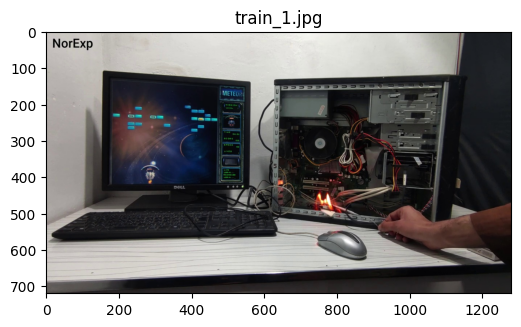

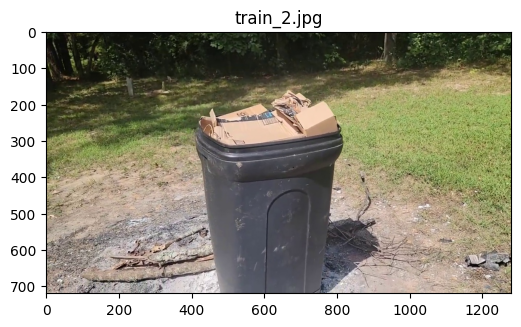

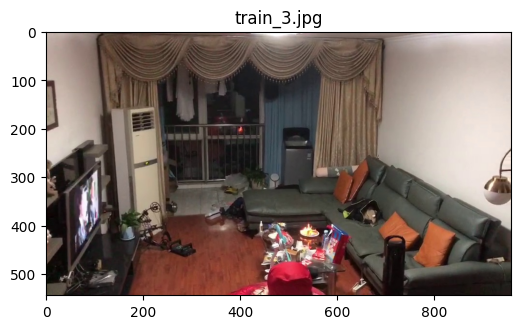

In [37]:
for i in range(1, 4):
    sample_image = DATA_DIR / "train" / "images" / f"train_{i}.jpg"
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(Image.open(sample_image))
    ax.set_title(sample_image.name)
    plt.show()

In [4]:
sample_label = DATA_DIR / "train" / "labels" / "train_1.txt"
print(sample_label.read_text())

0 0.60703125 0.6555555555555556 0.05625 0.08333333333333334



This is a YOLO format. With Class ID, x_center, y_center, width and height respectively. We want to understand which class ID is Smoke, which is Fire. We can see 0 is Fire and 1 is smoke when investigated dataset manually. Some images have both, some have more than 1 Fire etc. It is given line by line

Let's create a helper function to draw bounding boxes onto images

In [29]:
CLASS_IDS = {
    0: {"name": "fire", "color": "red"},
    1: {"name": "smoke", "color": "blue"}
}

In [ ]:
def draw_bbox(ax, label_path, img_path):
    img_w, img_h = Image.open(img_path).size
    
    for line in label_path.read_text().strip().splitlines(): # THere can be multiple lines (multiple bounding boxes)
        if not line.strip():
            continue

        cls_id, xc, yc, w, h = map(float, line.split())
        x = (xc - w / 2) * img_w # Calculate top-left x coordinate of the bounding box
        y = (yc - h / 2) * img_h # Calculate top-left y coordinate of the bounding box

        rect = plt.Rectangle(
            (x, y), w * img_w, h * img_h,
            fill=False,
            edgecolor=CLASS_IDS[int(cls_id)]["color"],
            linewidth=2,
        )
        ax.add_patch(rect)

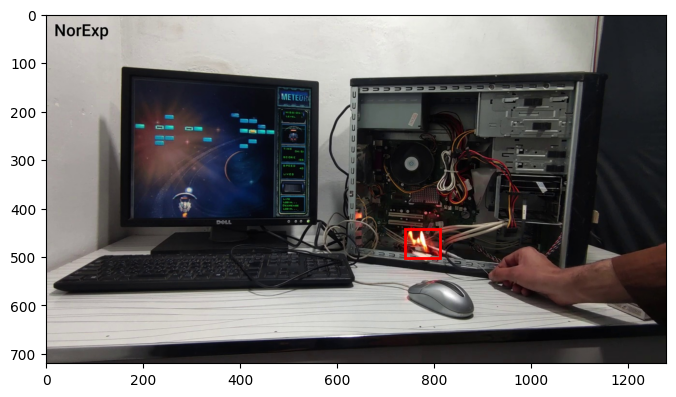

In [54]:
img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_1.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

Lets try another

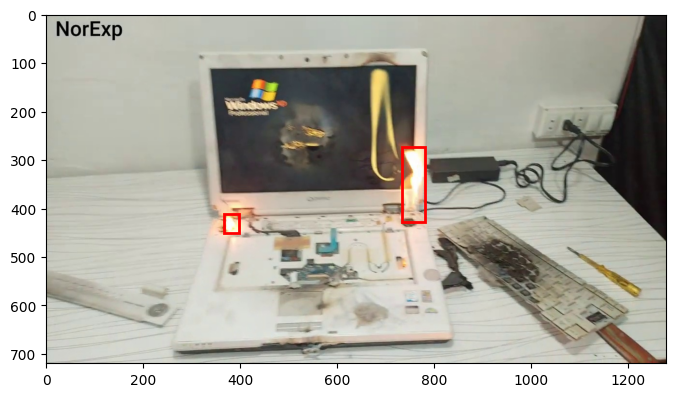

In [56]:
img_path = DATA_DIR / "train" / "images" / "train_4176.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4176.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

Try one with smokes

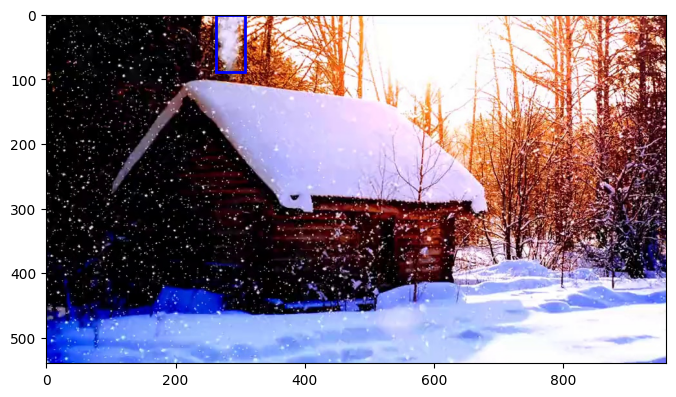

In [57]:
img_path = DATA_DIR / "train" / "images" / "train_4131.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4131.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

#### TODO: In the image we see above, there is sunlight, dense snow etc. So image is very hard to detect the smoke. So further on we will need to use some augmentation techniques to make model understand better.

Before training a model, we need to understand the dataset better.

In [94]:
class_counts = {0: 0, 1: 0}
box_areas = []
sizes = []
empty_labels = 0

for split in ["train", "val", "test"]:
    for label_path in (DATA_DIR / split / "labels").glob("*.txt"):
        img = DATA_DIR / split / "images" / f"{label_path.stem}.jpg"
        sizes.append(Image.open(img).size)

        lines = label_path.read_text().strip().splitlines()
        if not lines:
            empty_labels += 1
            continue

        for line in lines:
            cls_id, _, _, w, h = map(float, line.split())
            class_counts[int(cls_id)] += 1
            box_areas.append(w * h)

How many fire vs smoke bounding boxes are there? Is the dataset balanced?

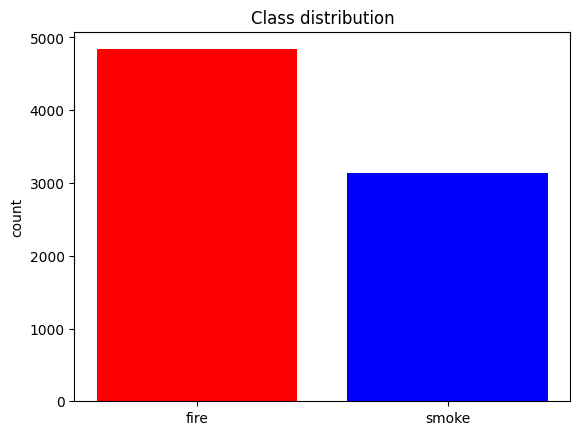

In [95]:
names = [CLASS_IDS[i]["name"] for i in class_counts]
counts = list(class_counts.values())

plt.bar(names, counts, color=["red", "blue"])
plt.title("Class distribution")
plt.ylabel("count")
plt.show()

Fire boxes are more common than smoke → use class weights or oversample smoke during training

Are all images the same size, or do we need to handle different resolutions?

In [96]:
sizes[:5]

[(1280, 720), (1280, 720), (1280, 720), (1280, 720), (1920, 1080)]

In [97]:
len(set(sizes))

45

No there is too many different sizes and resolutions, we want to look at how we can handle that. Yolo handles internally, but should research for other models we will use. Let's look at the distribution plot.

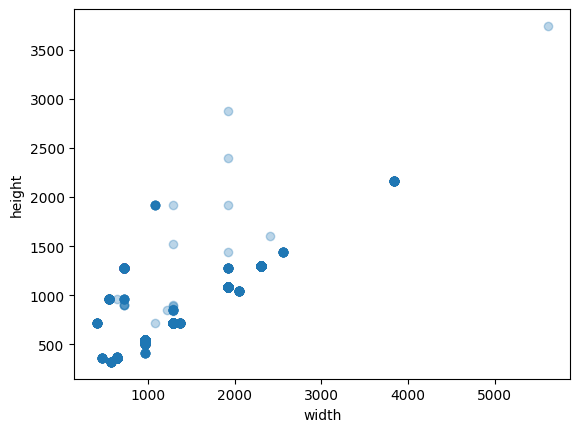

In [116]:
widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("width")
plt.ylabel("height")
plt.show()

Are there many small targets? Small objects are harder to detect.

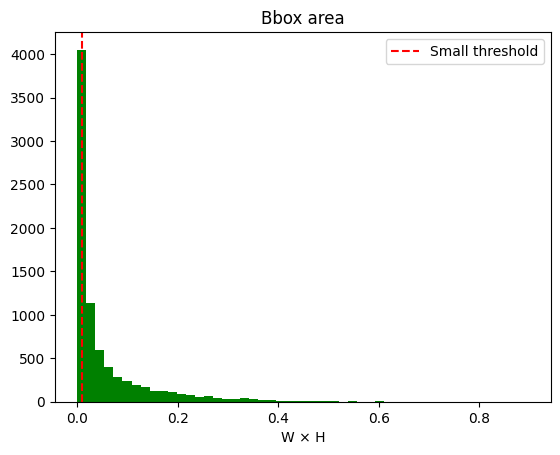

In [102]:
small_threshold = 0.01  # Lets say a bounding box is considered small when it is 1% of the image
plt.hist(box_areas, bins=50, color="green")
plt.axvline(small_threshold, color="red", linestyle="--", label="Small threshold")
plt.title("Bbox area")
plt.xlabel("W × H")
plt.legend()
plt.show()

In [ ]:
small = sum(1 for a in box_areas if a < small_threshold)
100 * small / len(box_areas)

39.55878666332414

About 40% of bounding boxes cover less than 1% (based on our choice) of the image area.

There is no separate "none" class in YOLO. Images with no fire or smoke have an empty label file. We should look at how many of these negative examples we have.

In [100]:
empty_labels

135